# Stress-Predict Datset

In [41]:
import pandas as pd

df = pd.read_csv("../../datasets/stress/raw/stress_no_features.csv")

In [42]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report", tsmode=True)

In [ ]:
profile.to_notebook_iframe()

In [4]:
df.describe()

,Participant,HR,respr,Time(sec),Label
count,112516.000000,112472.000000,112516.000000,1.125160e+05,112516.000000
mean,18.475470,80.216177,12.465482,1.645692e+09,0.327198
std,9.871133,12.732206,2.030810,8.179419e+05,0.469192
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191843,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743635,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877519,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112516 entries, 0 to 112515
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Participant  112516 non-null  int64  
 1   HR           112472 non-null  float64
 2   respr        112516 non-null  float64
 3   Time(sec)    112516 non-null  int64  
 4   Label        112516 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 4.3 MB


## HR

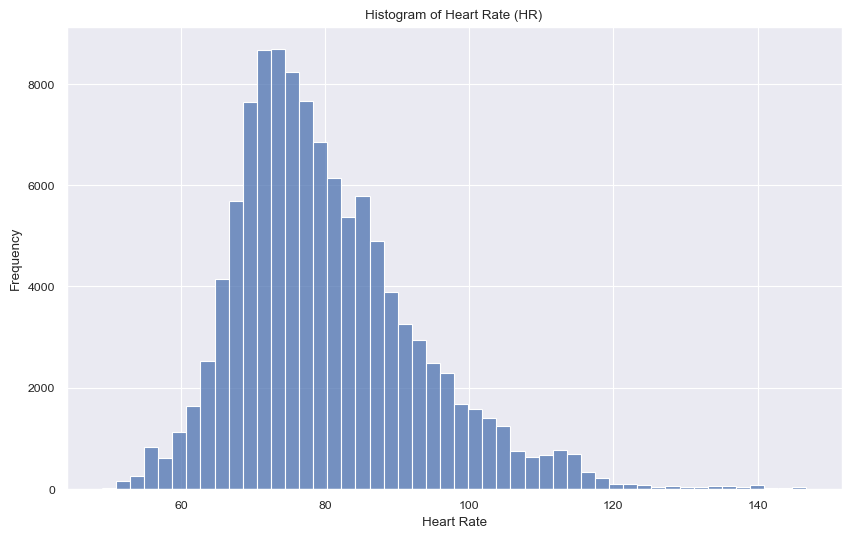

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["HR"], bins=50)
plt.title("Histogram of Heart Rate (HR)")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.savefig("../../datasets/stress/raw/plots/stress_hist.png", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

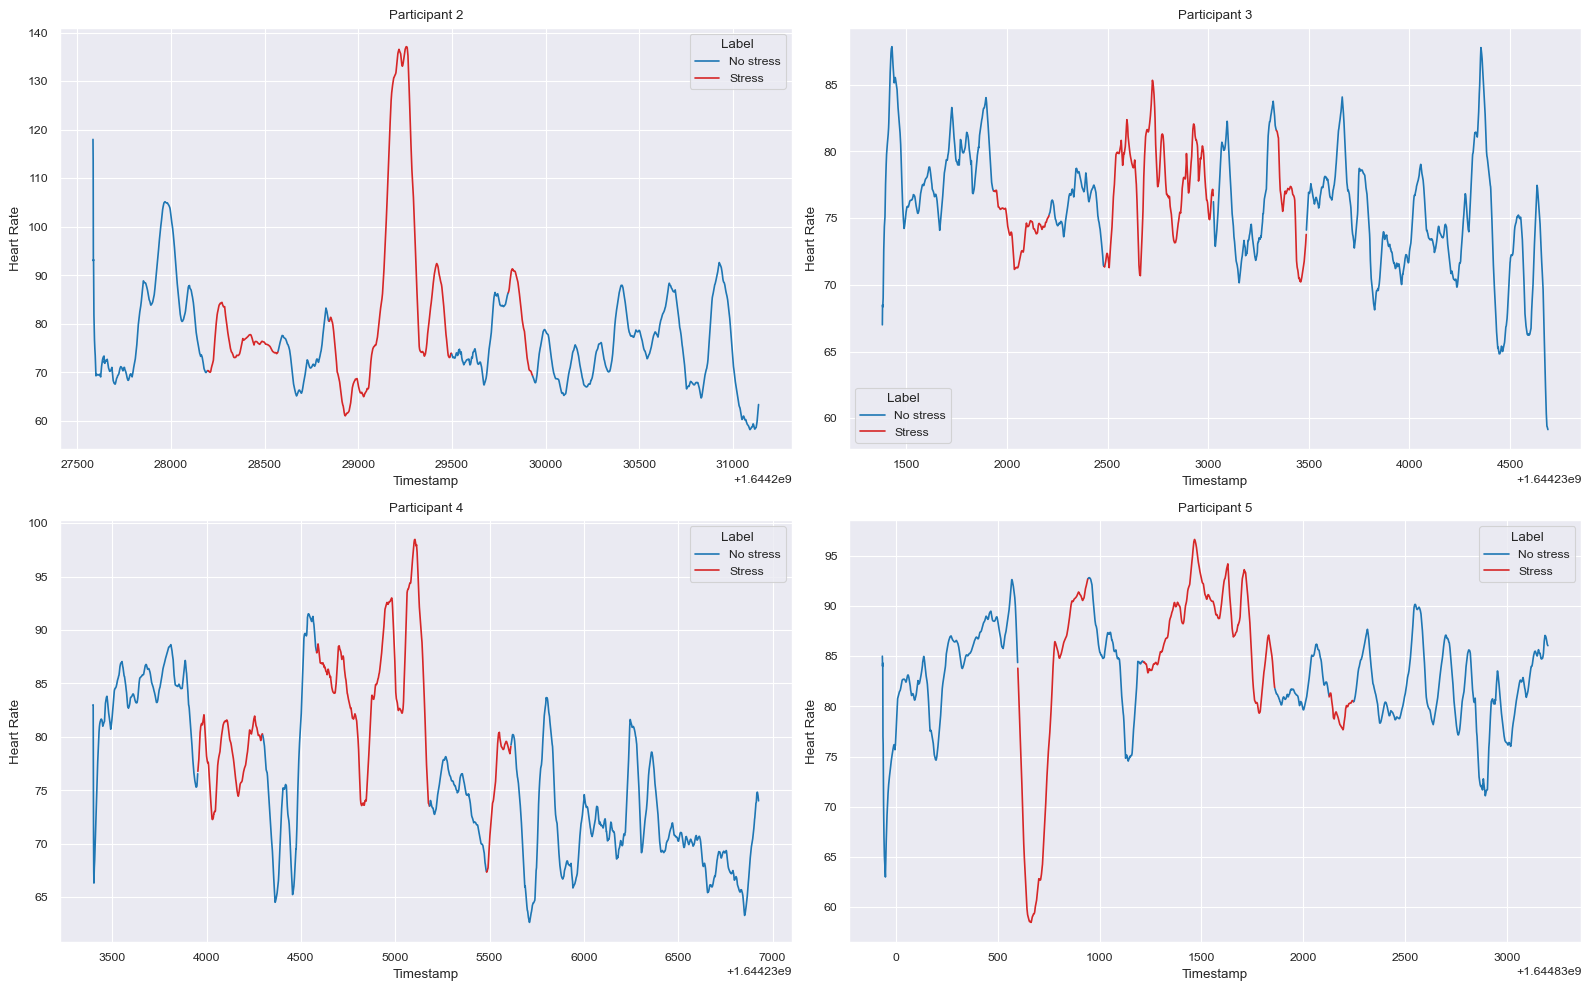

In [40]:
plt.figure(figsize=(12, 6))

color_map = {0: '#1f77b4', 1: '#d62728'}
label_map = {0: 'No stress', 1: 'Stress'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
participant_ids = sorted(df['Participant'].unique())[:4]

for ax, pid in zip(axes.flat, participant_ids):
    participant_data = df[df['Participant'] == pid].reset_index(drop=True)
    segments = []
    start_idx = 0
    for i in range(1, len(participant_data)):
        if participant_data.loc[i, 'Label'] != participant_data.loc[i-1, 'Label']:
            segments.append((start_idx, i))
            start_idx = i
    segments.append((start_idx, len(participant_data)))
    added_labels = set()
    for start, end in segments:
        segment = participant_data.iloc[start:end]
        label = segment['Label'].iloc[0]
        display_label = label_map[label]
        sns.lineplot(
            data=segment,
            x='Time(sec)',
            y='HR',
            color=color_map[label],
            label=display_label if display_label not in added_labels else None,
            ax=ax
        )
        added_labels.add(display_label)
    ax.set_title(f'Participant {pid}')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Heart Rate')
    ax.legend(title='Label')

plt.tight_layout()
plt.savefig("../../datasets/stress/raw/plots/hr_timeseries_4.png", dpi=600, bbox_inches="tight")
plt.show()

## RR

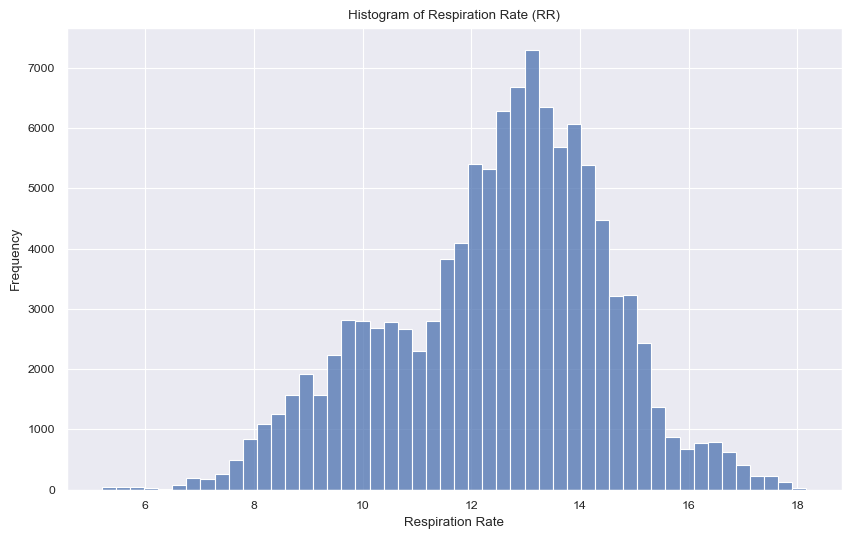

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["respr"], bins=50)
plt.title("Histogram of Respiration Rate (RR)")
plt.xlabel("Respiration Rate")
plt.ylabel("Frequency")
plt.savefig("../../datasets/stress/raw/plots/rr_hist.png", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

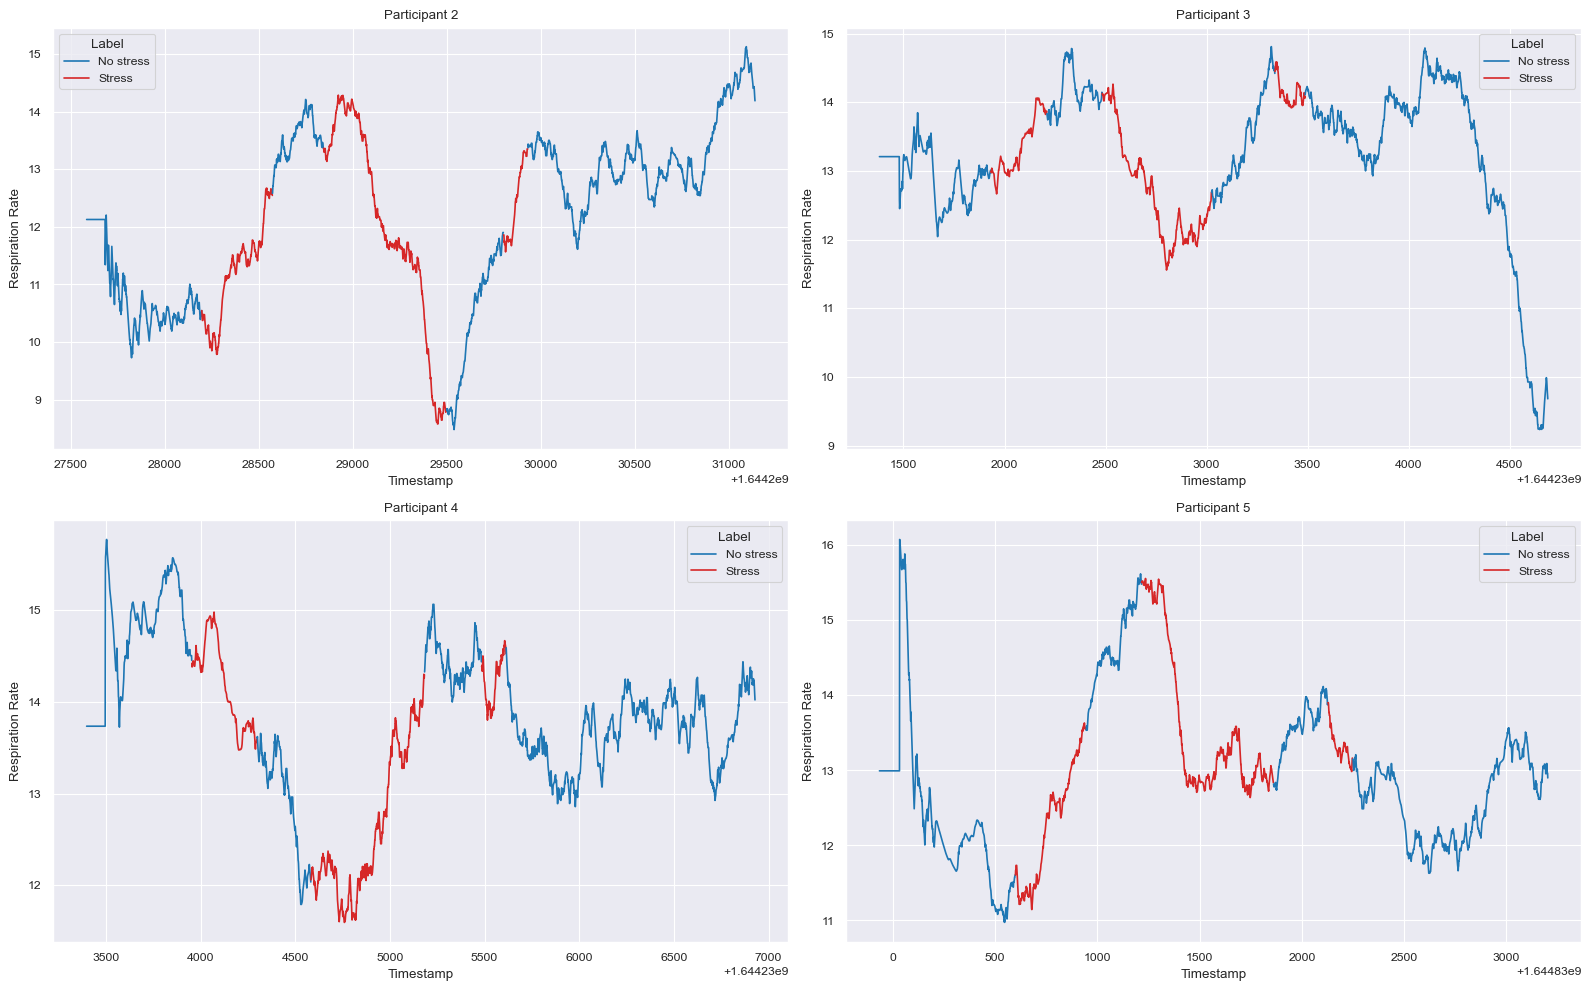

In [46]:
plt.figure(figsize=(12, 6))

color_map = {0: '#1f77b4', 1: '#d62728'}
label_map = {0: 'No stress', 1: 'Stress'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
participant_ids = sorted(df['Participant'].unique())[:4]

for ax, pid in zip(axes.flat, participant_ids):
    participant_data = df[df['Participant'] == pid].reset_index(drop=True)
    segments = []
    start_idx = 0
    for i in range(1, len(participant_data)):
        if participant_data.loc[i, 'Label'] != participant_data.loc[i-1, 'Label']:
            segments.append((start_idx, i))
            start_idx = i
    segments.append((start_idx, len(participant_data)))
    added_labels = set()
    for start, end in segments:
        segment = participant_data.iloc[start:end]
        label = segment['Label'].iloc[0]
        display_label = label_map[label]
        sns.lineplot(
            data=segment,
            x='Time(sec)',
            y='respr',
            color=color_map[label],
            label=display_label if display_label not in added_labels else None,
            ax=ax
        )
        added_labels.add(display_label)
    ax.set_title(f'Participant {pid}')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Respiration Rate')
    ax.legend(title='Label')

plt.tight_layout()
plt.savefig("../../datasets/stress/raw/plots/dataset_1_rr_timeseries_4.png", dpi=600, bbox_inches="tight")
plt.show()